# Project Phase 1
# Name : Maulik Sindhva
# Student id : 2434771

In [1]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torchvision.models import mobilenet_v2, shufflenet_v2_x1_0


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Running on device: {device}')

Running on device: cuda:0


## Data Loading


In [3]:
data_dir = "C:/Users/Admin/CNN/animal_10"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

total_len = len(full_dataset)
train_size = int(0.7 * total_len)
val_size = int(0.15 * total_len)
test_size = total_len - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)
# data loaders for mobile net
train_loader_1 = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_1 = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader_1 = DataLoader(test_dataset, batch_size=16, shuffle=False)

# data loaders for shuffle net
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", full_dataset.classes)

Train samples: 18325
Val samples: 3926
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


## Train , validation and test loops

In [4]:
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() #loss.item() converts the PyTorch tensor into a Python float
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()  #.sum().item() counts correct predictions for this batch and converts to Python int.

    return running_loss / len(train_loader), 100 * correct / total


def evaluate_model(model, val_loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return running_loss / len(val_loader), 100 * correct / total

def get_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


## Loss function

In [5]:
criterion = nn.CrossEntropyLoss()

## Mobilenet

In [6]:
mobilenet = mobilenet_v2(weights="IMAGENET1K_V1")

# Fully connected last layer should have 10 classes in the end
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 10)

mobilenet = mobilenet.to(device)

# Initialize optimizer for MobileNet
optimizer_mobilenet = optim.SGD(mobilenet.parameters(), lr=0.0005, momentum=0.9)

train_losses_mobilenet, val_losses_mobilenet = [], []
train_accuracies_mobilenet, val_accuracies_mobilenet = [], []
test_accuracies_mobilenet = [] # New list to store test accuracies

for epoch in range(10):
    train_loss, train_acc = train_model(mobilenet, train_loader_1, criterion, optimizer_mobilenet)
    val_loss, val_acc = evaluate_model(mobilenet, val_loader_1, criterion)
    _, test_acc = evaluate_model(mobilenet, test_loader_1, criterion) # Evaluate on test set

    train_losses_mobilenet.append(train_loss)
    val_losses_mobilenet.append(val_loss)
    train_accuracies_mobilenet.append(train_acc)
    val_accuracies_mobilenet.append(val_acc)
    test_accuracies_mobilenet.append(test_acc) # Store test accuracy

    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, Test Acc={test_acc:.2f}%")

torch.save(mobilenet.state_dict(), "mobilenet_animals_1_2.pth")

Epoch 1: Train Acc=89.94%, Val Acc=96.13%, Test Acc=96.03%
Epoch 2: Train Acc=95.72%, Val Acc=96.84%, Test Acc=96.49%
Epoch 3: Train Acc=97.30%, Val Acc=96.82%, Test Acc=96.69%
Epoch 4: Train Acc=98.21%, Val Acc=96.77%, Test Acc=96.49%
Epoch 5: Train Acc=98.58%, Val Acc=96.94%, Test Acc=96.44%
Epoch 6: Train Acc=99.06%, Val Acc=97.33%, Test Acc=96.82%
Epoch 7: Train Acc=99.41%, Val Acc=96.84%, Test Acc=96.69%
Epoch 8: Train Acc=99.37%, Val Acc=96.97%, Test Acc=96.92%
Epoch 9: Train Acc=99.61%, Val Acc=96.84%, Test Acc=96.79%
Epoch 10: Train Acc=99.60%, Val Acc=96.79%, Test Acc=96.79%


In [7]:
# Load the trained model
mobilenet.load_state_dict(torch.load("mobilenet_animals_1_2.pth"))
mobilenet.eval()

# Get true labels and predictions
y_true_1, y_pred_1 = get_predictions(mobilenet, test_loader)

# Print classification report
print("MobileNet Metrics:\n")
print(classification_report(y_true_1, y_pred_1, target_names=full_dataset.classes))

MobileNet Metrics:

              precision    recall  f1-score   support

        cane       0.96      0.98      0.97       730
     cavallo       0.97      0.96      0.96       391
    elefante       0.99      0.97      0.98       216
    farfalla       0.95      0.98      0.96       319
     gallina       0.99      0.97      0.98       477
       gatto       0.97      0.94      0.96       237
       mucca       0.93      0.95      0.94       280
      pecora       0.94      0.94      0.94       256
       ragno       0.99      0.98      0.98       710
  scoiattolo       0.97      0.98      0.97       312

    accuracy                           0.97      3928
   macro avg       0.97      0.96      0.96      3928
weighted avg       0.97      0.97      0.97      3928



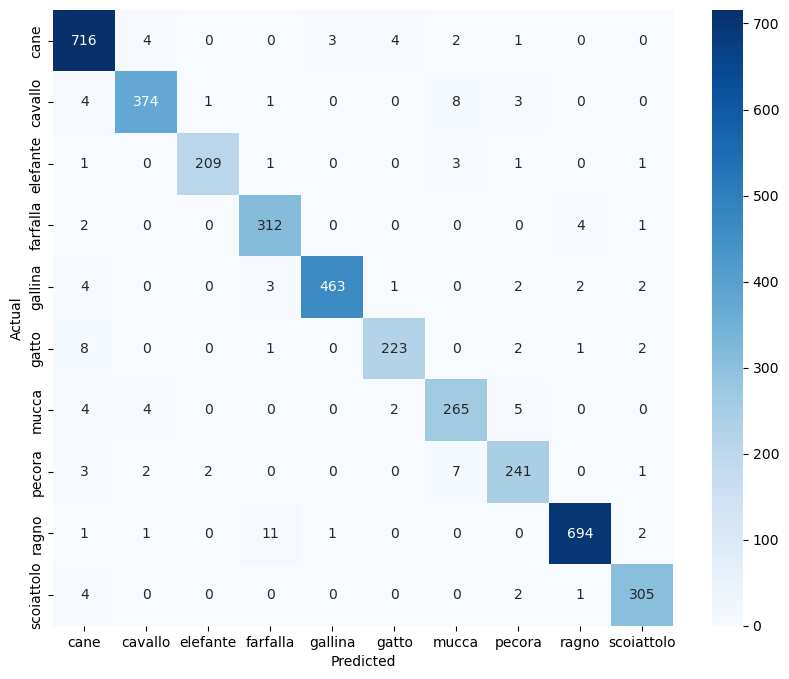

In [8]:
cm = confusion_matrix(y_true_1, y_pred_1)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Shufflenet

In [9]:
shufflenet = shufflenet_v2_x1_0(weights="IMAGENET1K_V1")

# Fully connected last layer should have 10 classes in the end
shufflenet.fc = nn.Linear(shufflenet.fc.in_features, 10)

shufflenet = shufflenet.to(device)

# Initialize optimizer for ShuffleNet
optimizer_shufflenet = optim.Adam(shufflenet.parameters(), lr=0.0001)

train_losses_shufflenet, val_losses_shufflenet = [], []
train_accuracies_shufflenet, val_accuracies_shufflenet = [], []
test_accuracies_shufflenet = [] # New list to store test accuracies

for epoch in range(10):
    train_loss, train_acc = train_model(shufflenet, train_loader, criterion, optimizer_shufflenet)
    val_loss, val_acc = evaluate_model(shufflenet, val_loader, criterion)
    _, test_acc = evaluate_model(shufflenet, test_loader, criterion) # Evaluate on test set

    train_losses_shufflenet.append(train_loss)
    val_losses_shufflenet.append(val_loss)
    train_accuracies_shufflenet.append(train_acc)
    val_accuracies_shufflenet.append(val_acc)
    test_accuracies_shufflenet.append(test_acc) # Store test accuracy

    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%, Test Acc={test_acc:.2f}%")

torch.save(shufflenet.state_dict(), "shufflenet_animals_1_2.pth")

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth


100%|█████████████████████████████████████████████████████████████████████████████| 8.79M/8.79M [00:00<00:00, 37.9MB/s]


Epoch 1: Train Acc=66.54%, Val Acc=88.67%, Test Acc=87.96%
Epoch 2: Train Acc=90.18%, Val Acc=94.42%, Test Acc=93.66%
Epoch 3: Train Acc=94.37%, Val Acc=95.01%, Test Acc=94.86%
Epoch 4: Train Acc=96.43%, Val Acc=95.67%, Test Acc=94.91%
Epoch 5: Train Acc=97.59%, Val Acc=95.31%, Test Acc=95.09%
Epoch 6: Train Acc=98.10%, Val Acc=95.08%, Test Acc=95.37%
Epoch 7: Train Acc=98.71%, Val Acc=95.42%, Test Acc=95.06%
Epoch 8: Train Acc=98.98%, Val Acc=95.62%, Test Acc=95.01%
Epoch 9: Train Acc=99.26%, Val Acc=95.06%, Test Acc=95.09%
Epoch 10: Train Acc=99.36%, Val Acc=95.62%, Test Acc=95.16%


In [10]:
# Load the trained model
shufflenet.load_state_dict(torch.load("shufflenet_animals_1_2.pth"))
shufflenet.eval()

# Get true labels and predictions
y_true, y_pred = get_predictions(shufflenet, test_loader)

# Print classification report
print("ShuffleNet Metrics:\n")
print(classification_report(y_true, y_pred, target_names=full_dataset.classes))

ShuffleNet Metrics:

              precision    recall  f1-score   support

        cane       0.93      0.95      0.94       730
     cavallo       0.96      0.93      0.94       391
    elefante       0.97      0.96      0.97       216
    farfalla       0.96      0.98      0.97       319
     gallina       0.97      0.96      0.97       477
       gatto       0.95      0.92      0.93       237
       mucca       0.90      0.89      0.89       280
      pecora       0.89      0.93      0.91       256
       ragno       0.99      0.97      0.98       710
  scoiattolo       0.95      0.97      0.96       312

    accuracy                           0.95      3928
   macro avg       0.95      0.95      0.95      3928
weighted avg       0.95      0.95      0.95      3928



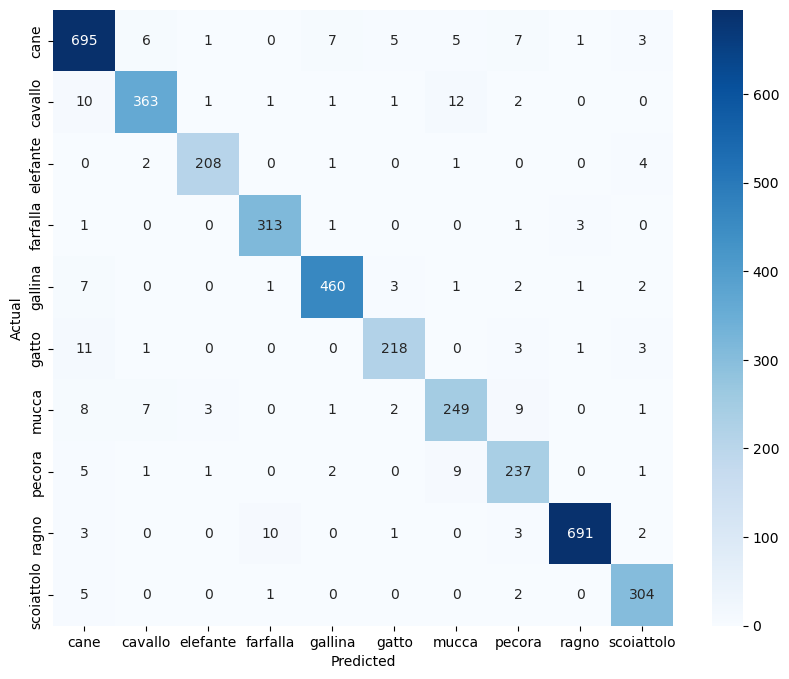

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Plots

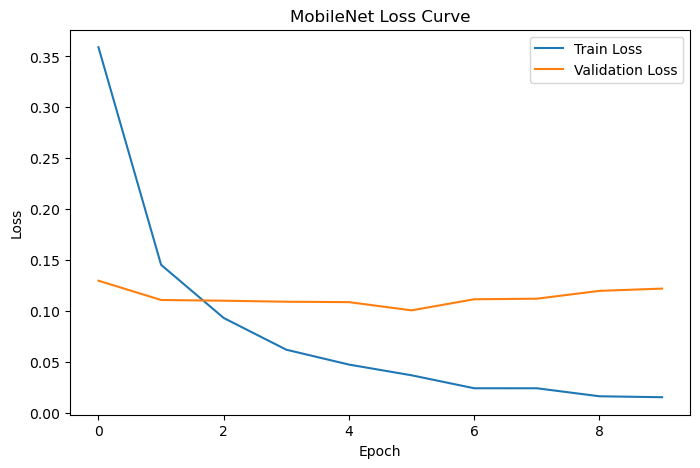

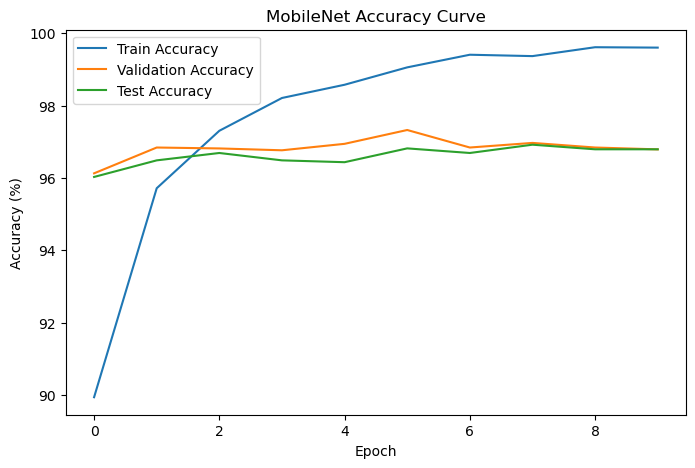

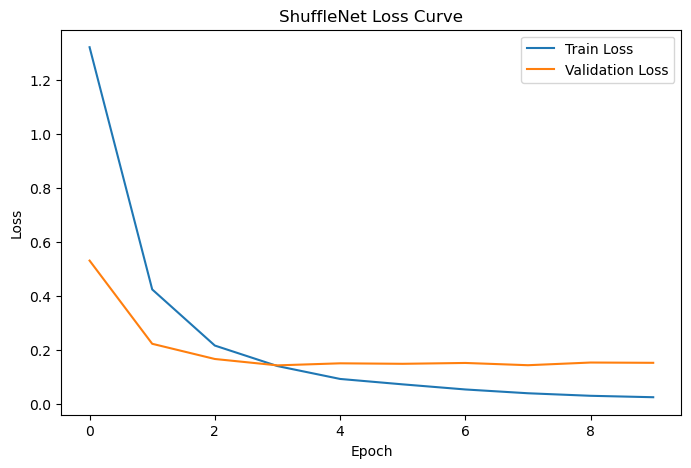

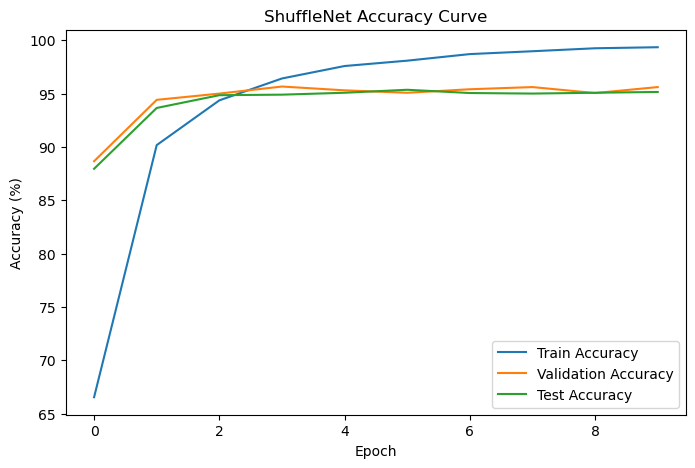

In [12]:
def plot_curves(train_losses, val_losses, train_acc, val_acc, test_acc, model_name):
    # Loss
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.plot(test_acc, label='Test Accuracy') # Plot test accuracy
    plt.title(f'{model_name} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

plot_curves(train_losses_mobilenet, val_losses_mobilenet, train_accuracies_mobilenet, val_accuracies_mobilenet, test_accuracies_mobilenet, "MobileNet")
plot_curves(train_losses_shufflenet, val_losses_shufflenet, train_accuracies_shufflenet, val_accuracies_shufflenet, test_accuracies_shufflenet, "ShuffleNet")